In [1]:
import warnings

import os
import torch
import pickle
import numpy as np
import os.path as osp
from tqdm import tqdm

from functools import reduce
import torch.nn.functional as F
import matplotlib.pyplot as plt
import albumentations as A

from src.datasets import DatasetBuilder
from src.models.classifiers import SimpleCNNtorch, build_resnet50
from src.models.vae import BetaVAEDerma
from src.models.vae_gan.autoencoder import AutoencoderKL
from src.cf_methods import Revise
from src.evaluation.local_instability import perturb_sample
from src.utils import extract_factual_instances, filter_valid_factuals
from src.utils import seed_everything, get_config, load_model_weights
from src.utils import evaluate_classification_model, plot_boxplot

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
I0000 00:00:1775806078.782571    4179 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
seed_everything()
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
# repo_path = r'D:\PycharmProjects\CF-Robustness-Benchmark'
repo_path = r'/teamspace/studios/this_studio/CF-Robustness-Benchmark'
config_path = r'configs/revise_derma_binary.yaml'
config = get_config(osp.join(repo_path, config_path))

In [4]:
ds_builder = DatasetBuilder(config)
ds_builder.setup()
train_loader, val_loader, test_loader = ds_builder.get_dataloaders()

imgs = ds_builder.train_dataset.data.imgs  # (N, H, W, 3), uint8 [0, 255]
mean = imgs.mean(axis=(0, 1, 2)) / 255.0   # per-channel mean
std = imgs.std(axis=(0, 1, 2)) / 255.0     # per-channel std

test_loader.dataset.transform = A.Compose(
            [A.Normalize(mean=mean.tolist(), std=std.tolist())])

In [5]:
def normalize(img_tensor, mean, std):
    """
    Apply normalization to an image tensor.
    Input: (C, H, W) tensor in range [0, 1].
    Output: Normalized tensor centered around 0.
    """
    # Convert lists to tensors and reshape for broadcasting: (C, 1, 1)
    mean = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    return (img_tensor - mean) / std
    
def denormalize(img_tensor, mean, std):
    """Reverse ImageNet normalization for visualization. 
    Input: (C, H, W) tensor."""
    mean = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    return torch.clamp(img_tensor * std + mean, 0, 1)

In [ ]:
images, labels = next(iter(test_loader))
print(images.min(), images.max())
denorm_images = denormalize(images, mean, std)
print(denorm_images.min(), denorm_images.max())
denorm_images_ = denorm_images * 2 - 1
print(denorm_images_.min(), denorm_images_.max())
norm_images = normalize(denorm_images, mean, std)
print(norm_images.min(), norm_images.max())


tensor(-4.5885) tensor(2.3925)
tensor(0.0118, dtype=torch.float64) tensor(0.9961, dtype=torch.float64)
tensor(-0.9765, dtype=torch.float64) tensor(0.9922, dtype=torch.float64)
tensor(-4.5885, dtype=torch.float64) tensor(2.3925, dtype=torch.float64)


In [7]:
os.makedirs(config.save_dir, exist_ok=True)
class_names = ds_builder.class_encodings
ds_name = config.data.name
print(ds_name, class_names)

dermamnist {0: 'benign keratosis-like lesions', 1: 'melanoma'}


### Load the classifier and VAE

In [8]:
device = 'cpu'

config.classifier.checkpoints_path = '/teamspace/studios/this_studio/CF-Robustness-Benchmark/notebooks/experiments/dermamnist_classification/binary/checkpoints/derma_resnet50_acc=0.79.pth'
baseline_classifier = build_resnet50(config.data.num_classes)
load_model_weights(baseline_classifier, 
                   weights_path=config.classifier.checkpoints_path, 
                   lightning_used=False)
baseline_classifier = baseline_classifier.to(device)
baseline_classifier.eval()
evaluate_classification_model(baseline_classifier, test_loader, config.data.num_classes, device=device)

device = config.accelerator

Accuracy for the test dataset: 79.052%


In [9]:
vae = AutoencoderKL(config.vae.params.ddconfig,
                    config.vae.params.lossconfig, 
                    embed_dim=config.vae.params.embed_dim,
                    ckpt_path=config.vae.checkpoints_path);

making attention of type 'vanilla' with 128 in_channels
making attention of type 'vanilla' with 128 in_channels
making attention of type 'vanilla' with 128 in_channels
Working with z of shape (1, 4, 16, 16) = 1024 dimensions.
making attention of type 'vanilla' with 128 in_channels
making attention of type 'vanilla' with 128 in_channels
making attention of type 'vanilla' with 128 in_channels
making attention of type 'vanilla' with 128 in_channels


loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
Restored from /teamspace/studios/this_studio/CF-Robustness-Benchmark/notebooks/experiments/derma_vae/binary/derma_vae_best.ckpt


In [10]:
vae = vae.to(device)
vae.eval();

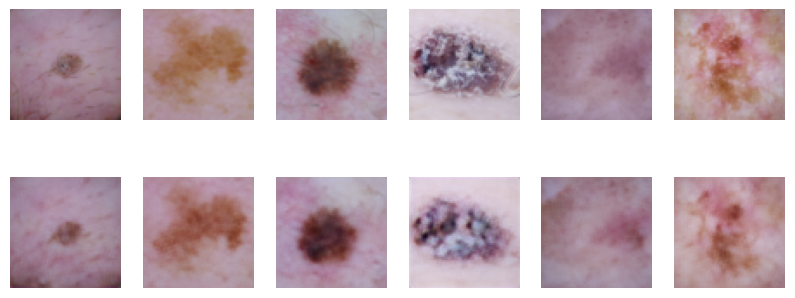

In [11]:

with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    # print(images.min(), images.max())
    denorm_images = (denormalize(images, mean, std) * 2 - 1).to(torch.float32)
    # print(denorm_images.min(), denorm_images.max())
    recon_images, _ = vae(denorm_images)
    # print(recon_images.min(), recon_images.max())

    recon_images = recon_images.to(device)
    recon_images = (recon_images.clamp(-1, 1) + 1) / 2
    # print(recon_images.min(), recon_images.max())

    # plot reconstructed images
    _, axes = plt.subplots(2, 6, figsize=(10, 4))
    for i in range(6):
        denorm_images = denormalize(images[i], mean=mean, std=std)
        axes[0, i].imshow(denorm_images.permute(1, 2, 0).cpu())
        axes[0, i].axis('off')
        axes[1, i].imshow(recon_images[i].permute(1, 2, 0).cpu())
        # axes[1, i].imshow(denormalize(recon_images[i], mean=mean, std=std).permute(1, 2, 0).cpu().squeeze())
        axes[1, i].axis('off')

### Preparing factual test instances and their perturbed versions

In [12]:
factuals, labels = extract_factual_instances(test_loader, init_class_idx=[0])
factuals, labels = filter_valid_factuals(factuals, labels, baseline_classifier, device)

In [13]:
# Checking for correctly predicted factuals 
preds = torch.argmax(baseline_classifier(factuals.to(device)), axis=1).detach().cpu()
print('Accuracy: {:.0%}'.format(torch.where(preds == labels)[0].shape[0] / factuals.shape[0]))

Accuracy: 100%


In [14]:
noise_magnitudes = [0.005, 0.01, 0.015, 0.02, 0.025]

Prepare perturbed factual instances for the generation of CFEs. We need those perturbed factuals that
are predicted correctly by the classifier

In [15]:
n = 100
factuals_pert = {}
indices_pert = {}

for noise in noise_magnitudes:
    denormalized_factuals = denormalize(factuals, mean, std)
    # print(denormalized_factuals.min(), denormalized_factuals.max())
    pert_sample = perturb_sample(denormalized_factuals, n_samples=1, epsilon=noise, 
                                type='uniform', channels_first=True).squeeze(1)
    pert_sample = torch.Tensor(pert_sample)

    # Check whether perturbed instances lead to the same class prediction
    norm_pert_sample = normalize(pert_sample.to(device), mean, std).to(torch.float32)
    # print(norm_pert_sample.min(), norm_pert_sample.max())

    predictions = torch.argmax(baseline_classifier(norm_pert_sample), axis=1).detach().cpu()
    indices = np.where(predictions == labels)[0]
    print(f'Number of valid perturbed factuals for the added noise level {noise}: ', indices.shape[0])
    factuals_pert[noise] = pert_sample
    indices_pert[noise] = indices

final_indices = reduce(np.intersect1d, list(indices_pert.values()))
factuals_pert = {k : v[final_indices][:n] for k, v in factuals_pert.items()}
factuals = factuals[final_indices][:n]
labels = labels[final_indices][:n]

Number of valid perturbed factuals for the added noise level 0.005:  163
Number of valid perturbed factuals for the added noise level 0.01:  164


Number of valid perturbed factuals for the added noise level 0.015:  162
Number of valid perturbed factuals for the added noise level 0.02:  162
Number of valid perturbed factuals for the added noise level 0.025:  163


Visualize the factual instances perturbed with different noise magnitude

# Generate CFEs

In [16]:
class AutoencoderKLWrapper:
    """Wrapper around AutoencoderKL to expose a simple .encoder/.decoder API
    compatible with the _counterfactual_optimization method."""

    def __init__(self, autoencoder_kl, mean, std):
        self._ae = autoencoder_kl
        self._mean = torch.tensor(mean).view(3, 1, 1).float()
        self._std = torch.tensor(std).view(3, 1, 1).float()


    class _Encoder:
        def __init__(self, ae, mean, std):
            self._ae = ae
            self._mean = mean
            self._std = std

        def __call__(self, x):
            # classifier space (normalized) → [0,1] → [-1,1]
            x = torch.clamp(x * self._std.to(x.device) + self._mean.to(x.device), 0, 1)  # de-normalize to [0,1]
            x = x * 2 - 1  
            # print(x.shape)  
            posterior = self._ae.encode(x)
            return posterior.mode(), posterior.logvar


        def parameters(self):
            return list(self._ae.encoder.parameters()) + list(self._ae.quant_conv.parameters())

    class _Decoder:
        def __init__(self, ae, mean, std):
            self._ae = ae
            self._mean = mean
            self._std = std

        def __call__(self, z):
            out = self._ae.decode(z)
            out = (out.clamp(-1, 1) + 1) / 2                             # [-1,1] → [0,1]
            out = (out - self._mean.to(out.device)) / self._std.to(out.device)  # [0,1] → classifier space
            return out

        def parameters(self):
            return list(self._ae.post_quant_conv.parameters()) + list(self._ae.decoder.parameters())

    @property
    def encoder(self):
        return self._Encoder(self._ae, self._mean, self._std)

    @property
    def decoder(self):
        return self._Decoder(self._ae, self._mean, self._std)

    def to(self, device):
        self._ae = self._ae.to(device)
        return self

    def eval(self):
        self._ae.eval()
        return self

In [17]:
wrapped_vae = AutoencoderKLWrapper(vae, mean, std)

In [18]:
with torch.no_grad():
    sample, _ = next(iter(test_loader))
    sample = sample.to(device).to(torch.float32)

    print("=== Classifier input (normalized) ===")
    print(f"  min={sample.min():.3f}, max={sample.max():.3f}")  # expect ~[-2, 2]

    # Simulate what _Encoder does
    vae_input = sample * torch.tensor(std).view(3,1,1).to(device) + torch.tensor(mean).view(3,1,1).to(device)
    vae_input = vae_input * 2 - 1
    print("=== VAE encoder input ===")
    print(f"  min={vae_input.min():.3f}, max={vae_input.max():.3f}")  # expect [-1, 1]

    # Run through VAE
    z, _ = wrapped_vae.encoder(sample)
    recon = wrapped_vae.decoder(z)
    print("=== Decoder output (back to classifier space) ===")
    print(f"  min={recon.min():.3f}, max={recon.max():.3f}")  # expect same range as classifier input

    print("=== Range match (classifier input vs reconstruction) ===")
    print(f"  input:  [{sample.min():.3f}, {sample.max():.3f}]")
    print(f"  recon:  [{recon.min():.3f}, {recon.max():.3f}]")


=== Classifier input (normalized) ===
  min=-4.588, max=2.392
=== VAE encoder input ===
  min=-0.976, max=0.992
=== Decoder output (back to classifier space) ===
  min=-5.263, max=2.490
=== Range match (classifier input vs reconstruction) ===
  input:  [-4.588, 2.392]
  recon:  [-5.263, 2.490]


In [19]:
target_class = "melanoma"
target_class_ind = 1
hparams = config.revise_hyperparameters
hparams['max_iter'] = 1000
hparams['lambda'] = 0.01
hparams['lr'] = 0.01
hparams['target_class_ind'] = np.zeros((1, config.data.num_classes))
hparams['target_class_ind'][0, target_class_ind] = 1
revise_method = Revise(baseline_classifier, wrapped_vae, hparams)

In [20]:
hparams

{'lambda': 0.01,
 'optimizer': 'Adam',
 'lr': 0.01,
 'max_iter': 1000,
 'target_class_ind': array([[0., 1.]])}

In [21]:
cfes = revise_method.get_counterfactuals(factuals[:10], verbose=False)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [01:29<00:00, 11.17it/s]


In [29]:
indices  =  [i for i, cfe in enumerate(cfes)  if not isinstance(cfe, list)]
indices

[7, 9]

In [ ]:
fname = f'cfes_{ds_name.lower()}_{target_class}.pkl'
with open(osp.join(config.save_dir, fname), 'wb') as f:
    pickle.dump(cfes, f)

In [49]:
ds_builder.class_encodings

{0: 'benign keratosis-like lesions', 1: 'melanoma'}

tensor(-0.5529) tensor(0.9216) torch.Size([3, 64, 64])
tensor(0.0617, dtype=torch.float64) tensor(0.7946, dtype=torch.float64) torch.Size([3, 64, 64])


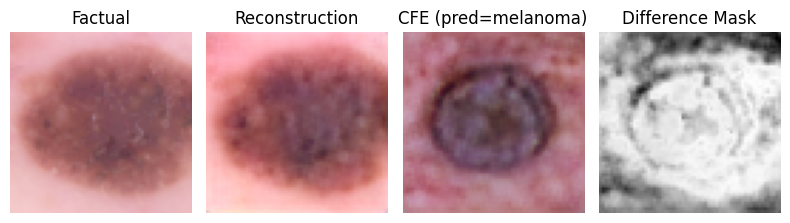

In [54]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def binary_difference_map(factual, cfe, threshold=0.05):
    """
    factual: torch.Tensor (C, H, W)
    cfe:     np.ndarray  (C, H, W)
    threshold: pixel-wise absolute difference above which a pixel is "changed"
    """
    factual_np = factual.cpu().numpy()           # (C, H, W)
    cfe_np = np.array(cfe)                       # (C, H, W)

    diff = np.abs(factual_np - cfe_np)           # (C, H, W)
    diff_gray = diff.mean(axis=0)                # (H, W) — average over channels
    binary_map = (diff_gray > threshold).astype(np.uint8)

    return diff_gray, binary_map

class_map = ds_builder.class_encodings
ind = 9
factual = factuals[ind]   # (C, H, W) tensor
cfe = cfes[ind]           # (C, H, W) ndarray

diff_gray, binary_map = binary_difference_map(factual, cfe, threshold=0.05)

fig, axs = plt.subplots(1, 4, figsize=(8, 4))
# fig, axs = plt.subplots(1, 4, figsize=(14, 4))

axs[0].imshow(denormalize(factual, mean, std).permute(1, 2, 0).cpu())
axs[0].set_title("Factual")

denorm_images = (denormalize(factual, mean, std) * 2 - 1).to(torch.float32)
print(denorm_images.min(), denorm_images.max(), denorm_images.shape)
recon_images, _ = vae(denorm_images.unsqueeze(0))
# print(recon_images.min(), recon_images.max())
recon_images = recon_images.to(device)
recon_images = (recon_images.clamp(-1, 1) + 1) / 2

axs[1].imshow(recon_images.squeeze(0).detach().permute(1,2,0), vmin=0, vmax=1)
axs[1].set_title(f"Reconstruction")

denorm_cfe  = denormalize(torch.Tensor(cfe), mean, std)
print(denorm_cfe.min(), denorm_cfe.max(), denorm_cfe.shape)
pred_cfe = baseline_classifier(normalize(denorm_cfe, mean, std).to(torch.float32).unsqueeze(0))
axs[2].imshow(denorm_cfe.permute(1, 2, 0).cpu())
axs[2].set_title(f"CFE (pred={class_map[torch.argmax(pred_cfe, axis=-1).item()]})")

axs[3].imshow(diff_gray, cmap="Grays")
axs[3].set_title("Difference Mask")



for ax in axs:
    ax.axis("off")
plt.tight_layout()
# plt.savefig('/teamspace/studios/this_studio/CF-Robustness-Benchmark/cf_output/derma/revise_binary/revise_cfes_binary_with_recon.png', dpi=300)
plt.show()


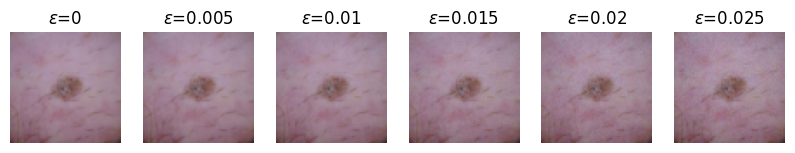

In [111]:
ind = 20
n_rows = 1
n_cols = len(noise_magnitudes) + 1
fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 4))

for j in range(n_cols):
    if j == 0: 
        axs[j].imshow(denormalize(factuals[ind], mean=mean, std=std).permute(1, 2, 0).cpu().numpy())
        axs[j].set_title('$\\epsilon$=0') 
        axs[j].axis('off')
    else:
        noise = noise_magnitudes[j-1]
        pert_image = factuals_pert[noise][ind]
        axs[j].imshow(pert_image.permute(1, 2, 0).numpy(), cmap='gray')
        axs[j].set_title('$\\epsilon$='+str(noise)) 
        axs[j].axis('off')
        
plt.show()

Read already generated CFEs

In [25]:
fname = f'cfes_{ds_name.lower()}_{target_class}.pkl'
with open(osp.join(config.save_dir, fname), 'rb') as f:
    cfes = pickle.load(f)

In [19]:
def normalize(img_tensor, mean, std):
    """Apply ImageNet normalization. Input: (C, H, W) or (N, C, H, W) tensor in [0, 1]."""
    mean = torch.tensor(mean).view(3, 1, 1).float()
    std  = torch.tensor(std).view(3, 1, 1).float()
    return (img_tensor.float() - mean) / std


In [20]:
cfes_pert = {} 

for noise in noise_magnitudes:
    norm_factuals_pert = normalize(factuals_pert[noise],  mean=mean, std=std)
    cfes_pert[noise] = revise_method.get_counterfactuals(norm_factuals_pert, 
                                                         verbose=False)
    fname = f'cfes_{ds_name.lower()}_{target_class}_noise_{noise}.pkl'
    with open(osp.join(config.save_dir, fname), 'wb') as f:
        pickle.dump(cfes_pert[noise], f)

100%|██████████| 1000/1000 [11:49<00:00,  1.41it/s]


Read already generated perturbed CFEs

In [16]:
cfes_pert = {} 

for noise in noise_magnitudes:
    fname = f'cfes_{ds_name.lower()}_{target_class}_noise_{noise}.pkl'
    with open(osp.join(config.save_dir, fname), 'rb') as f:
        cfes_pert[noise] = pickle.load(f)

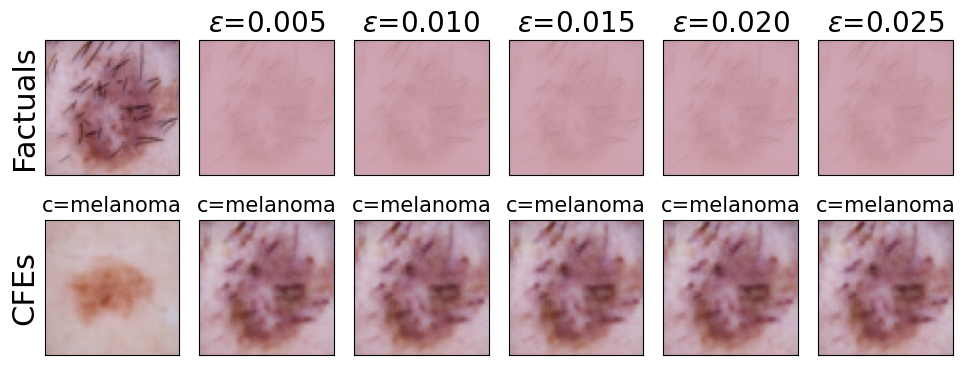

In [30]:
n_rows = 2
n_cols = 6

ind = 5
factuals_vis = [factuals[ind]] + [factuals_pert[noise][ind] for noise in noise_magnitudes]
cfes_vis = [cfes[ind]] + [cfes_pert[noise][ind] for noise in noise_magnitudes]

fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 4), sharex=True, sharey=True)
for j in range(n_cols):
    pert_image = denormalize(factuals_vis[j], mean=mean, std=std).numpy().transpose(1, 2, 0) 
    axs[0, j].imshow(pert_image)
    if j > 0:
        noise = noise_magnitudes[j-1]
        axs[0, j].set_title('$\\epsilon$={:.3f}'.format((noise)), fontsize=20) 
    
    axs[1, j].imshow(denormalize(torch.Tensor(cfes_vis[j]), mean=mean, std=std).permute(1,2,0))
    if j == 0:
        axs[0, j].set_ylabel('Factuals', fontsize=22)
        axs[1, j].set_ylabel('CFEs', fontsize=22)
    pred = torch.argmax(baseline_classifier(torch.Tensor(cfes_vis[j]).unsqueeze(0).to(config.accelerator)), 
    axis=1).item()
    axs[1, j].set_title(f'c={target_class if pred == target_class_ind else pred}', fontsize=15)

plt.tight_layout()
plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[]);
plt.show()

## Local Instability

In [36]:
from src.evaluation.local_instability import calculate_sparsity, calculate_ssim

Checking validity of explanations after perturbation

In [57]:
len(cfes)

10

In [31]:
validity = 0
for cfe in cfes:
    if len(cfe) !=0:
        out = baseline_classifier(torch.Tensor(cfe).unsqueeze(0).to(config.accelerator))
        pred = torch.argmax(out, axis=1).detach().cpu().item()
        if pred == target_class_ind:    
            validity += 1
validity /= len(cfes)
print('Initial validity: ', validity)

Initial validity:  0.28


In [58]:
len([cfe for cfe in cfes if not isinstance(cfe, list)])

2

In [34]:
validity_list = []
for noise in noise_magnitudes:
    predictions = []
    validity = 0
    total_cfes_found = len(cfes_pert[noise])
    for i, cfe_pert in enumerate(cfes_pert[noise]):
        if len(cfe_pert) == 0:
            continue

        predictions = torch.argmax(baseline_classifier(torch.Tensor(cfe_pert).unsqueeze(0).to(config.accelerator)), axis=1).detach().cpu()
        if predictions == target_class_ind: 
            validity += 1 
    validity /= total_cfes_found
    validity_list.append(validity)
    print(f'Validity for the added noise level {noise}: ',  validity)

fname = f'{ds_name.lower()}_{target_class}_validity.pkl'
with open(osp.join(config.save_dir, fname), 'wb') as f:
    pickle.dump(validity_list, f)

Validity for the added noise level 0.005:  0.24
Validity for the added noise level 0.01:  0.24
Validity for the added noise level 0.015:  0.23
Validity for the added noise level 0.02:  0.23
Validity for the added noise level 0.025:  0.22


In [37]:
instability_l1_list = []
ssim_list = []

for noise, cfe_pert_list in cfes_pert.items():
    l1_temp = []
    ssim_temp = []
    for i in range(len(cfes[:50])):
        cf = cfes[i]
        cf_pert = cfe_pert_list[i]

        if len(cf) != 0 and len(cf_pert) != 0:

            cf_tensor = torch.Tensor(cf)
            cf = cf_tensor.permute(1, 2, 0).flatten()

            cf_pert_tensor = torch.Tensor(cf_pert)
            cf_perturbed = cf_pert_tensor.permute(1, 2, 0).flatten()        

            l1_distance = sum(abs(cf - cf_perturbed)).item() 
            l1_temp.append(l1_distance)

            ssim = calculate_ssim(cf_tensor.unsqueeze(0), cf_pert_tensor.unsqueeze(0)).item()
            ssim_temp.append(ssim)

    instability_l1_list.append(l1_temp)
    ssim_list.append(ssim_temp)

with open(osp.join(config.save_dir, f'{ds_name.lower()}_{target_class}_li_l1.pkl'), 'wb') as f:
    pickle.dump(instability_l1_list, f)

with open(osp.join(config.save_dir, f'{ds_name.lower()}_{target_class}_ssim.pkl'), 'wb') as f:
    pickle.dump(ssim_list, f)

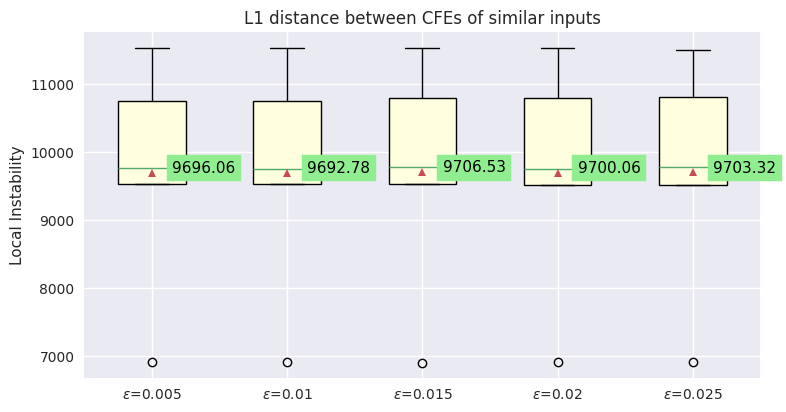

In [38]:
import pandas as pd
plt.style.use("seaborn-v0_8")
plt.rcParams['figure.figsize'] = [8, 4]

plot_boxplot(data=instability_l1_list, mean_values=[np.mean(li).round(2) for li in instability_l1_list],
            tick_labels=[f'$\\epsilon$={noise_level}' for noise_level in noise_magnitudes],
            y_label='Local Instability', colors=['lightyellow'], 
            title='L1 distance between CFEs of similar inputs')

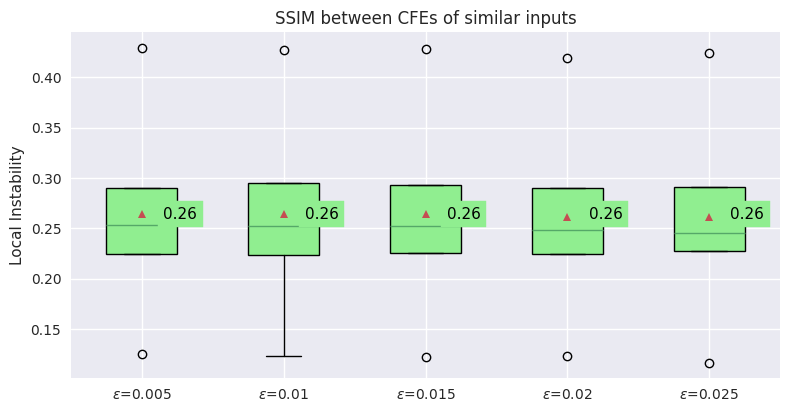

In [39]:
plot_boxplot(data=ssim_list, mean_values=[np.mean(li).round(2) for li in ssim_list],
             tick_labels=[f'$\\epsilon$={noise_level}' for noise_level in noise_magnitudes],
             y_label='Local Instability', colors=['lightgreen'], title='SSIM between CFEs of similar inputs')

## Local Lipschitz Continuity

In [30]:
original_points = factuals[:50]
original_cfes = cfes[:50]
print("Are the lengths of initial points (factuals) and CFEs generated for them equal :", len(original_cfes) == original_points.shape[0])

Are the lengths of initial points (factuals) and CFEs generated for them equal : True


In [42]:
noise_magnitude = 0.001
n_samples = 30
revise_method._params["max_iter"] = 900

lip_estimates = []

i = 0
for original_point, original_cfe in tqdm(zip(original_points[:n_samples], original_cfes[:n_samples])):
    if isinstance(original_cfe, list):
        continue
    neighbor_points = perturb_sample(original_point, 
                                    n_samples=n_samples, 
                                    epsilon=noise, 
                                    type='uniform', 
                                    channels_first=True)

    neighbor_points = torch.Tensor(neighbor_points).squeeze(0)
    neighbor_cfes = revise_method.get_counterfactuals(neighbor_points, verbose=False)

    lip_estimate = 0
    for m, p in tqdm(zip(neighbor_cfes, neighbor_points)):
        if not isinstance(m, list):
            num = np.linalg.norm((original_cfe - m).flatten(), ord=2) 
            denom = np.linalg.norm((original_point - p).flatten(), ord=2)
            lip = num / denom
            lip_estimate = max(lip, lip_estimate)

    lip_estimates.append(lip_estimate)
    i += 1

100%|██████████| 1000/1000 [01:17<00:00, 12.87it/s]
30it [00:00, 53227.21it/s]
100%|██████████| 1000/1000 [01:19<00:00, 12.62it/s]
30it [00:00, 10025.43it/s]
100%|██████████| 1000/1000 [01:19<00:00, 12.65it/s]
30it [00:00, 11678.96it/s]
100%|██████████| 1000/1000 [01:18<00:00, 12.81it/s]
30it [00:00, 3060.87it/s]
100%|██████████| 1000/1000 [01:19<00:00, 12.64it/s]
30it [00:00, 11995.15it/s]
100%|██████████| 1000/1000 [01:19<00:00, 12.64it/s]
30it [00:00, 11171.90it/s]
100%|██████████| 1000/1000 [01:19<00:00, 12.65it/s]
30it [00:00, 2497.80it/s]
100%|██████████| 1000/1000 [01:18<00:00, 12.81it/s]
30it [00:00, 111451.83it/s]
100%|██████████| 1000/1000 [01:19<00:00, 12.58it/s]
30it [00:00, 11301.34it/s]
100%|██████████| 1000/1000 [01:18<00:00, 12.80it/s]
30it [00:00, 46863.73it/s]
100%|██████████| 1000/1000 [01:18<00:00, 12.81it/s]
30it [00:00, 194480.87it/s]
100%|██████████| 1000/1000 [01:18<00:00, 12.66it/s]
30it [00:00, 11685.47it/s]
100%|██████████| 1000/1000 [01:17<00:00, 12.84it/s]


In [43]:
with open(osp.join(config.save_dir, f'{ds_name.lower()}_{target_class}_lle.pkl'), 'wb') as f:
        pickle.dump(lip_estimates, f)

## Invalidation Rate

In [25]:
classifiers_weights_dir = r"/teamspace/studios/this_studio/CF-Robustness-Benchmark/notebooks/experiments/derma_classification/binary/checkpoints/mc_2_4"

classifiers_list = []
for clf_weights in os.listdir(classifiers_weights_dir):
    cnn_perturbed = SimpleCNNtorch(**config.classifier.args,
                                    img_size=config.data.img_size)
    load_model_weights(model=cnn_perturbed, 
                        weights_path=osp.join(classifiers_weights_dir, clf_weights), 
                        lightning_used=True)
    classifiers_list.append(cnn_perturbed)
    evaluate_classification_model(cnn_perturbed, 
                                    dataloader=test_loader, 
                                    num_classes=config.data.num_classes)

Accuracy for the test dataset: 98.682%
Accuracy for the test dataset: 97.705%
Accuracy for the test dataset: 97.607%
Accuracy for the test dataset: 97.705%
Accuracy for the test dataset: 97.803%
Accuracy for the test dataset: 96.484%
Accuracy for the test dataset: 97.266%
Accuracy for the test dataset: 97.705%
Accuracy for the test dataset: 98.193%
Accuracy for the test dataset: 97.852%


In [26]:
validity_list = []
invalidation_rate_list = []

for i, classifier in enumerate(classifiers_list):
    validity = 0
    invalidation_rate = 0
    total_found_cfs = 0
    
    for cfe in cfes:
        if isinstance(cfe, list):
            continue
        
        cfe = torch.Tensor(cfe).unsqueeze(0).to(device)
        classifier.eval()
        with torch.no_grad():
            classifier = classifier.to(device)

            baseline_pred = torch.argmax(baseline_classifier(cfe), axis=1)
            alternative_pred = torch.argmax(classifier(cfe), axis=1)

        total_found_cfs += 1

        if baseline_pred != alternative_pred:
            invalidation_rate += 1

        if alternative_pred == target_class_ind:
                validity += 1

    invalidation_rate /= total_found_cfs
    validity /= total_found_cfs 
    invalidation_rate_list.append(invalidation_rate)
    validity_list.append(validity)
    print(f'Model {i}: IR={np.round(invalidation_rate, 4)}, validity={np.round(validity, 4)}')

print('Average IR : {:.3f} +- {:.3f}'.format(np.mean(invalidation_rate_list), np.std(invalidation_rate_list)))
print('Average VaR : {:.3f} +- {:.3f}'.format(np.mean(validity_list), np.std(validity_list)))

Model 0: IR=0.3587, validity=0.6413
Model 1: IR=0.7283, validity=0.2717
Model 2: IR=0.9022, validity=0.0978
Model 3: IR=0.8804, validity=0.1196
Model 4: IR=0.8913, validity=0.1087
Model 5: IR=0.5217, validity=0.4783
Model 6: IR=0.75, validity=0.25
Model 7: IR=0.6957, validity=0.3043
Model 8: IR=0.8043, validity=0.1957
Model 9: IR=0.8478, validity=0.1522
Average IR : 0.738 +- 0.167
Average VaR : 0.262 +- 0.167


## Relaxed Stability

In [27]:
k = 1000
sigma = 0.001

average_stability_list = []
for i, classifier in enumerate(classifiers_list):
    stability_list = []
    for cfe in cfes:
        if isinstance(cfe, list):
            continue

        cfe = torch.Tensor(cfe).unsqueeze(0)
        cfe_sampled = torch.Tensor(perturb_sample(cfe, n_samples=k, noise_magnitude=sigma))

        with torch.no_grad():
            cf_logits = classifier(cfe.to(device))
            cf_probabilities = F.softmax(cf_logits, dim=-1)[:, target_class_ind]

            cf_sampled_logits = classifier(cfe_sampled.to(device))
            cf_sampled_probabilities = F.softmax(cf_sampled_logits, dim=-1)[:, target_class_ind]
        
        model_variance = abs(cf_probabilities - cf_sampled_probabilities)

        stability = (cf_sampled_probabilities - model_variance).mean()
        stability_list.append(stability.item())

    avg_i_stability = np.mean(stability_list)
    print('Stability of the model {}: {:.3f} +- {:.3f}'.format(i, avg_i_stability.item(), np.std(stability_list).item()))
    average_stability_list.append(avg_i_stability)

Stability of the model 0: 0.497 +- 0.293
Stability of the model 1: 0.246 +- 0.305
Stability of the model 2: 0.110 +- 0.167
Stability of the model 3: 0.182 +- 0.204
Stability of the model 4: 0.149 +- 0.235
Stability of the model 5: 0.473 +- 0.322
Stability of the model 6: 0.241 +- 0.321
Stability of the model 7: 0.298 +- 0.310
Stability of the model 8: 0.246 +- 0.245
Stability of the model 9: 0.175 +- 0.247


In [36]:
print('Average RS: {:.3f} +- {:.3f}'.format(np.mean(average_stability_list), np.std(average_stability_list)))

Average RS: 0.262 +- 0.123


## LOF

In [29]:
from src.evaluation.lof import estimate_anom_cfe_in_target_class

In [30]:
cfes_array = np.array([cfe for cfe in cfes if not isinstance(cfe, list)])
cfes_array.shape

(92, 1, 28, 28)

In [31]:
target_class_ascores, target_class_classes = estimate_anom_cfe_in_target_class(5, [target_class_ind], -1.1, test_loader, cfes_array)
print('Average negative LOF (the lower values the more anomaluous): {:.3f} +- {:.3f}'.format(np.mean(target_class_ascores), 
                                                                                            np.std(target_class_ascores)))

Average negative LOF (the lower values the more anomaluous): -1.490 +- 0.221


In [32]:
anomaly_scores, anomaly_classes = estimate_anom_cfe_in_target_class(5, [0, 1, 2, 3], -1.1, test_loader, cfes_array)
print('Average negative LOF (the lower values the more anomaluous): {:.3f} +- {:.3f}'.format(np.mean(anomaly_scores), np.std(anomaly_scores)))

Average negative LOF (the lower values the more anomaluous): -1.375 +- 0.228


In [33]:
config.save_dir

'/data/leuven/365/vsc36567/CF-Robustness-Benchmark/cf_output/fmnist/revise_binary'

In [34]:
# couldn't save bc of the finished session 
with open(osp.join(config.save_dir, f'fmnist_{target_class}_ir_var_rs_lof.pkl'), 'wb') as f:
    pickle.dump({'ir': (np.mean(invalidation_rate_list), np.std(invalidation_rate_list)),
                'var': (np.mean(validity_list), np.std(validity_list)),
                'rs': (np.mean(average_stability_list), np.std(average_stability_list)),
                'lof_target_class': (np.mean(target_class_ascores), np.std(target_class_ascores)),
                'lof_test_set': (np.mean(anomaly_scores), np.std(anomaly_scores))
                }, f)